In [1]:
%matplotlib inline
# standard libraries
import numpy as np
import scipy as sp
import pandas as pd
import glob,os,re
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# image related libraries
import os
import cv2
from skimage.filters import threshold_otsu
from scipy.ndimage import distance_transform_edt,convolve
import seaborn as sns
import skimage
from skimage.transform import resize
from skimage import io
from PIL import Image
from tensorflow.keras.preprocessing.image import load_img, img_to_array
# ML packages 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
# TDA related libraries
import cripser, tcripser
from ripser import ripser
import persim
import gudhi
import PersistenceImages.persistence_images as pimg
from persim.landscapes import PersLandscapeExact
from persim.landscapes import plot_landscape_simple
from persim.landscapes import PersistenceLandscaper
from persim import PersistenceImager
from persim import plot_diagrams

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

In [ ]:
def dt(img,radius=None,signed=False):
    if radius is not None:
      from skimage.filters import rank
      from skimage.morphology import disk, ball
      bw_img = (img >= rank.otsu(img, disk(radius)))
    else:
      bw_img = (img >= threshold_otsu(img))
    dt_img = distance_transform_edt(bw_img)
    if signed:
        dt_img -= distance_transform_edt(~bw_img)
    return(dt_img)

In [48]:
def dt(img,radius=None,signed=False):
    if radius is not None:
      from skimage.filters import rank
      from skimage.morphology import disk, ball
      bw_img = (img >= rank.otsu(img, disk(radius)))
    else:
      bw_img = (img >= threshold_otsu(img))
    dt_img = distance_transform_edt(bw_img)
    if signed:
        dt_img -= distance_transform_edt(~bw_img)
    return(dt_img)

In [2]:
import numpy as np

def compute_extended_persistent_statistics(pds):
    def safe_entropy(persistence):
        if len(persistence) == 0 or np.sum(persistence) == 0:
            return 0
        p_norm = persistence / np.sum(persistence)
        return -np.sum(p_norm * np.log(p_norm + 1e-10))

    feature_vectors = []

    for pd_diagram_filtered in pds:
        features = []

        for dim in range(2):  # For H0 and H1
            pd = pd_diagram_filtered[dim]

            if pd.shape[0] == 0:
                # All-zero features for empty diagrams
                features.extend([0]*12)
                continue

            birth_times = pd[:, 0]
            death_times = pd[:, 1]
            pers = death_times - birth_times

            # Core stats
            mean_persistence = np.mean(pers)
            max_persistence = np.max(pers)
            std_persistence = np.std(pers)
            total_persistence = np.sum(pers)
            total_persistence_squared = np.sum(pers ** 2)
            entropy = safe_entropy(pers)

            # Lifespan bins
            short = np.sum(pers < 0.05)
            medium = np.sum((pers >= 0.05) & (pers < 0.15))
            long = np.sum(pers >= 0.15)

            # Append features
            features.extend([ mean_persistence, max_persistence, std_persistence,
                total_persistence, total_persistence_squared, entropy,
                short, medium, long
            ])

        feature_vectors.append(features)

    return np.array(feature_vectors)


In [3]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def load_40X_images_rgb_channels(base_path):
    R_channel_images = []
    G_channel_images = []
    B_channel_images = []
    labels = []

    main_categories = ['benign', 'malignant']  # or pass as a parameter

    for label_idx, category in enumerate(main_categories):  
        category_path = os.path.join(base_path, category, "SOB")
        if not os.path.exists(category_path):
            continue
        diagnosis_folders = os.listdir(category_path)

        for diagnosis in diagnosis_folders:
            diagnosis_path = os.path.join(category_path, diagnosis)
            if not os.path.isdir(diagnosis_path):
                continue
            patient_folders = os.listdir(diagnosis_path)

            for patient in patient_folders:
                patient_path = os.path.join(diagnosis_path, patient)
                mag_folder_path = os.path.join(patient_path, "40X")
                if not os.path.exists(mag_folder_path):
                    continue

                image_files = os.listdir(mag_folder_path)
                for img_file in image_files:
                    img_path = os.path.join(mag_folder_path, img_file)
                    try:
                        img = load_img(img_path, target_size=(150, 150), color_mode='rgb')
                        img_array = img_to_array(img).astype('float32') / 255.0

                        # Separate channels
                        R_channel_images.append(img_array[:, :, 0])
                        G_channel_images.append(img_array[:, :, 1])
                        B_channel_images.append(img_array[:, :, 2])
                        labels.append(label_idx)
                    except Exception as e:
                        print(f"Error loading image {img_path}: {e}")

    return {
        'R': R_channel_images,
        'G': G_channel_images,
        'B': B_channel_images,
        'labels': labels
    }


In [5]:
data = load_40X_images_rgb_channels(base_path=r"D:\Breast cancer images\BreaKHis_v1\BreaKHis_v1\histology_slides\breast")

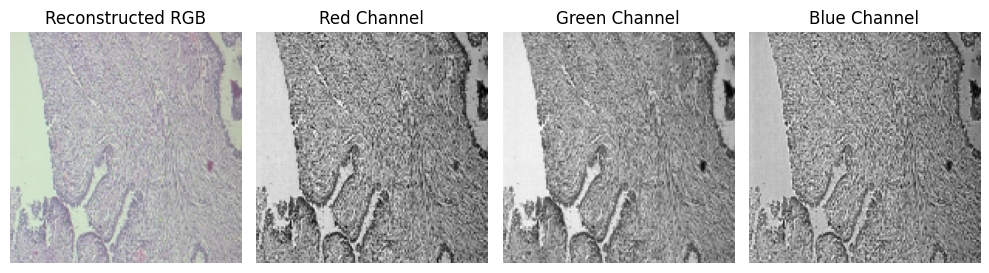

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Let's say you already ran:
# data = load_40X_images_rgb_channels(base_path="your/path")

def show_rgb_channels(data, n):
    R = data['R'][n]
    G = data['G'][n]
    B = data['B'][n]

    # Stack to reconstruct color image for visual check
    reconstructed_rgb = np.stack([R, G, B], axis=-1)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(reconstructed_rgb)
    plt.title('Reconstructed RGB')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(R, cmap='gray')
    plt.title('Red Channel')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(G, cmap='gray')
    plt.title('Green Channel')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(B, cmap='gray')
    plt.title('Blue Channel')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage for image index n = 0
show_rgb_channels(data, n=230)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

# Assuming you already loaded your data with the function above
# Convert lists to NumPy arrays
R = np.array(data['R'])  # shape: (n_samples, 150, 150)
G = np.array(data['G'])
B = np.array(data['B'])
y = np.array(data['labels'])

# Flatten and concatenate R, G, B channels: shape -> (n_samples, 150*150*3)
X = np.concatenate([
    R.reshape(R.shape[0], -1),
    G.reshape(G.shape[0], -1),
    B.reshape(B.shape[0], -1)
], axis=1)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM
clf = SVC(kernel='linear')  # You can try 'rbf', 'poly', etc.
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.7820


In [8]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))


Classification Report:
              precision    recall  f1-score   support

      Benign       0.72      0.57      0.64       134
   Malignant       0.80      0.89      0.84       265

    accuracy                           0.78       399
   macro avg       0.76      0.73      0.74       399
weighted avg       0.78      0.78      0.78       399



In [9]:
def filter_persistence_diagrams(channel_data):
    pds = []

    for image in channel_data:
        pd = cripser.computePH(image, maxdim=1)

        # Separate by dimension (0 and 1) and keep birth-death only
        pd_diagram = [pd[pd[:, 0] == dim, 1:3] for dim in range(2)]

        # Filter out features with death >= 1
        pd_diagram_filtered = [
            pd_diagram[i][pd_diagram[i][:, 1] < 1]  # Keep only features where death < 1
            for i in range(2)
        ]

        pds.append(pd_diagram_filtered)

    return pds


# Use for each channel
pds_R = filter_persistence_diagrams(R)
pds_G = filter_persistence_diagrams(G)
pds_B = filter_persistence_diagrams(B)

    

# Persistent Images

In [31]:
def generate_persistent_images(pds):
    PI_h0 = []
    PI_h1 = []
    
    for pd_diagram in pds:
        pimgr = PersistenceImager(pixel_size=0.01)
        
        # For H0 (dimension 0)
        pimgr.fit(pd_diagram[0])  
        pimgr.kernel_params = {'sigma': 0.001}  
        pimgr_transformed_0 = pimgr.transform(pd_diagram[0])  

        # For H1 (dimension 1)
        pimgr.fit(pd_diagram[1]) 
        pimgr_transformed_1 = pimgr.transform(pd_diagram[1])  
        
        # Append the persistent images to the respective lists
        PI_h0.append(pimgr_transformed_0)
        PI_h1.append(pimgr_transformed_1)
    
    return PI_h0, PI_h1

# Apply to the different datasets
PI_R_h0, PI_R_h1 = generate_persistent_images(pds_R)
PI_G_h0, PI_G_h1 = generate_persistent_images(pds_G)
PI_B_h0, PI_B_h1 = generate_persistent_images(pds_B)
 

In [41]:
def resize_images(images, target_shape=(100, 100)):
    resized_images = []
    for img in images:
        resized_img = resize(img, target_shape, mode='reflect', anti_aliasing=True)
        resized_images.append(resized_img)
    return resized_images

# Resize all persistent images to a fixed size (100, 100)
PI_R_h0_resized = resize_images(PI_R_h0, target_shape=(100, 100))
PI_G_h0_resized = resize_images(PI_G_h0, target_shape=(100, 100)) 
PI_B_h0_resized = resize_images(PI_B_h0, target_shape=(100, 100))
PI_R_h1_resized = resize_images(PI_R_h1, target_shape=(100, 100)) 
PI_G_h1_resized = resize_images(PI_G_h1, target_shape=(100, 100))
PI_B_h1_resized = resize_images(PI_B_h1, target_shape=(100, 100)) 

# Function to flatten images from 2D to 1D
def flatten_images(images):
    return [img.flatten() for img in images]

# Flatten the resized images for both dimensions
PI_R_h0_flatten = flatten_images(PI_R_h0_resized)
PI_G_h0_flatten = flatten_images(PI_G_h0_resized)
PI_B_h0_flatten = flatten_images(PI_B_h0_resized)

PI_R_h1_flatten = flatten_images(PI_R_h1_resized)
PI_G_h1_flatten = flatten_images(PI_G_h1_resized)
PI_B_h1_flatten = flatten_images(PI_B_h1_resized)

# Convert to numpy arrays
PI_R_h0_np = np.array(PI_R_h0_flatten)
PI_G_h0_np = np.array(PI_G_h0_flatten)
PI_B_h0_np = np.array(PI_B_h0_flatten)
PI_R_h1_np = np.array(PI_R_h1_flatten)
PI_G_h1_np = np.array(PI_G_h1_flatten)
PI_B_h1_np = np.array(PI_B_h1_flatten)

In [43]:
combined_features = np.hstack([PI_R_h0_np, PI_G_h0_np, PI_B_h0_np]) 
X_train, X_test, y_train, y_test = train_test_split(combined_features, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Random Forest Classifier (Combined Features): {accuracy:.4f}")
print("\nClassification Report (Combined Features):")
print(classification_report(y_test, y_pred))

Accuracy of the Random Forest Classifier (Combined Features): 0.4185

Classification Report (Combined Features):
              precision    recall  f1-score   support

           0       0.32      0.63      0.42       134
           1       0.63      0.31      0.41       265

    accuracy                           0.42       399
   macro avg       0.47      0.47      0.42       399
weighted avg       0.52      0.42      0.42       399



In [44]:
combined_features = np.hstack([PI_R_h1_np, PI_G_h1_np, PI_B_h1_np]) 
X_train, X_test, y_train, y_test = train_test_split(combined_features, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Random Forest Classifier (Combined Features): {accuracy:.4f}")
print("\nClassification Report (Combined Features):")
print(classification_report(y_test, y_pred))

Accuracy of the Random Forest Classifier (Combined Features): 0.2982

Classification Report (Combined Features):
              precision    recall  f1-score   support

           0       0.26      0.59      0.36       134
           1       0.42      0.15      0.22       265

    accuracy                           0.30       399
   macro avg       0.34      0.37      0.29       399
weighted avg       0.37      0.30      0.27       399



In [47]:
combined_features = np.hstack([PI_R_h0_np, R_stats]) 
X_train, X_test, y_train, y_test = train_test_split(combined_features, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Random Forest Classifier (Combined Features): {accuracy:.4f}")
print("\nClassification Report (Combined Features):")
print(classification_report(y_test, y_pred))

Accuracy of the Random Forest Classifier (Combined Features): 0.5213

Classification Report (Combined Features):
              precision    recall  f1-score   support

           0       0.34      0.46      0.39       134
           1       0.67      0.55      0.60       265

    accuracy                           0.52       399
   macro avg       0.51      0.51      0.50       399
weighted avg       0.56      0.52      0.53       399



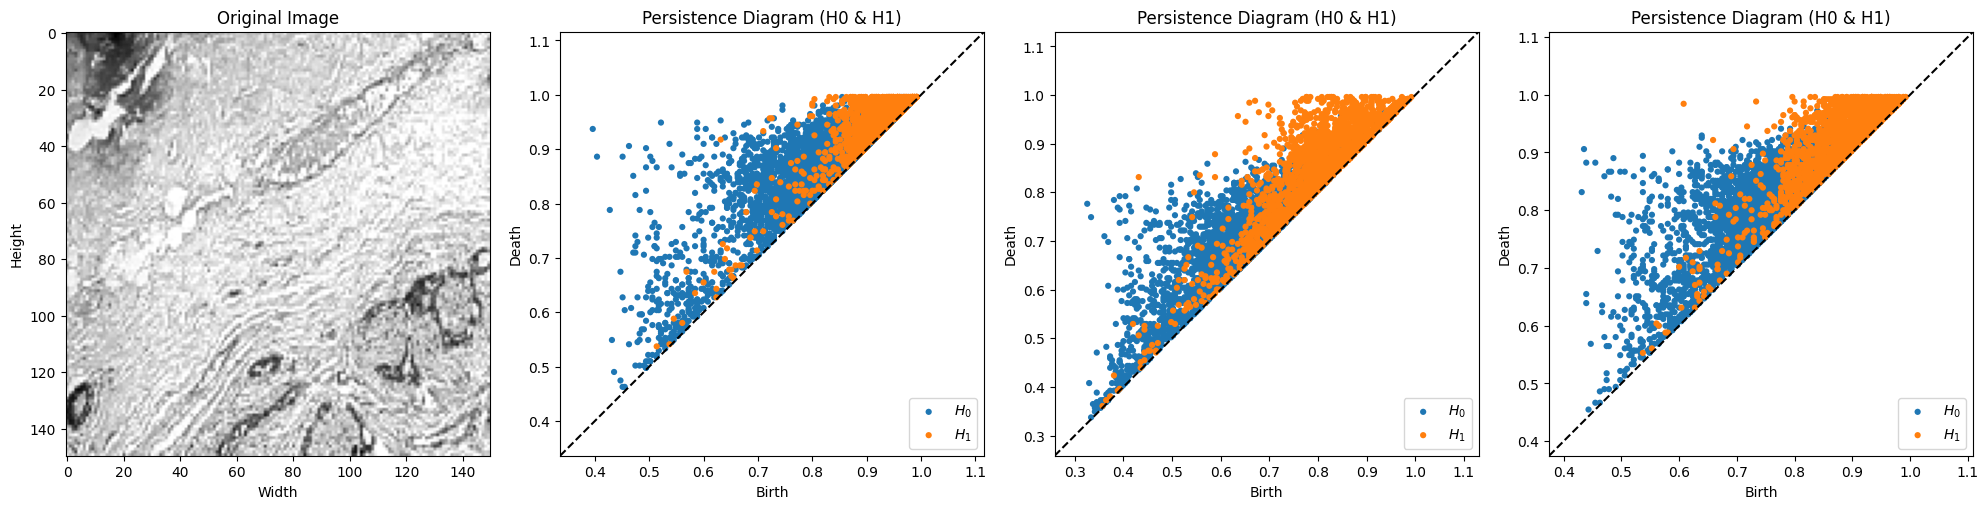

In [10]:
n = 123
pd_diagram = pds_R[n]

fig, axs = plt.subplots(1, 4, figsize=(20, 5))  # 4 subplots now!

# Display original grayscale image
axs[0].imshow(R[n], cmap="gray")
axs[0].set_title("Original Image")
axs[0].set_xlabel("Width")
axs[0].set_ylabel("Height")

persim.plot_diagrams(pds_R[n], ax=axs[1])
axs[1].set_title("Persistence Diagram (H0 & H1)")
axs[1].set_xlabel("Birth")
axs[1].set_ylabel("Death")

persim.plot_diagrams(pds_G[n], ax=axs[2])
axs[2].set_title("Persistence Diagram (H0 & H1)")
axs[2].set_xlabel("Birth")
axs[2].set_ylabel("Death")

persim.plot_diagrams(pds_B[n], ax=axs[3])
axs[3].set_title("Persistence Diagram (H0 & H1)")
axs[3].set_xlabel("Birth")
axs[3].set_ylabel("Death")

plt.tight_layout()
plt.show()

# Persistent Statistics

In [11]:
R_stats = compute_extended_persistent_statistics(pds_R)
G_stats = compute_extended_persistent_statistics(pds_B)
B_stats = compute_extended_persistent_statistics(pds_G)


In [12]:
R_stats

array([[4.56787900e-02, 3.52941185e-01, 4.98013715e-02, ...,
        1.60500000e+03, 3.42000000e+02, 3.00000000e+00],
       [3.63203312e-02, 3.01960796e-01, 4.16521132e-02, ...,
        1.72900000e+03, 2.98000000e+02, 4.00000000e+00],
       [3.17671086e-02, 3.05882365e-01, 3.72244964e-02, ...,
        1.80700000e+03, 2.54000000e+02, 1.00000000e+00],
       ...,
       [1.21090663e-01, 6.78431362e-01, 1.11315962e-01, ...,
        2.10000000e+02, 1.10000000e+02, 2.30000000e+01],
       [1.13806691e-01, 6.66666657e-01, 1.04026978e-01, ...,
        7.90000000e+01, 3.10000000e+01, 2.00000000e+00],
       [1.37165472e-01, 8.94117646e-01, 1.32192757e-01, ...,
        1.44000000e+02, 4.70000000e+01, 7.00000000e+00]])

In [13]:
combined_features = np.hstack([R_stats, G_stats, B_stats]) 

In [30]:
X_train, X_test, y_train, y_test = train_test_split(G_stats, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Random Forest Classifier (Combined Features): {accuracy:.4f}")
print("\nClassification Report (Combined Features):")
print(classification_report(y_test, y_pred))

Accuracy of the Random Forest Classifier (Combined Features): 0.8221

Classification Report (Combined Features):
              precision    recall  f1-score   support

           0       0.84      0.58      0.69       134
           1       0.82      0.94      0.88       265

    accuracy                           0.82       399
   macro avg       0.83      0.76      0.78       399
weighted avg       0.82      0.82      0.81       399



In [15]:
X_train, X_test, y_train, y_test = train_test_split(combined_features, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Random Forest Classifier (Combined Features): {accuracy:.4f}")
print("\nClassification Report (Combined Features):")
print(classification_report(y_test, y_pred))

Accuracy of the Random Forest Classifier (Combined Features): 0.8722

Classification Report (Combined Features):
              precision    recall  f1-score   support

           0       0.91      0.69      0.78       134
           1       0.86      0.97      0.91       265

    accuracy                           0.87       399
   macro avg       0.88      0.83      0.85       399
weighted avg       0.88      0.87      0.87       399



In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Assuming X and y are your combined persistent feature vectors and labels
X = np.concatenate([R_stats, G_stats, B_stats], axis=1)
y = np.array(data['labels'])

# Scale (important for SVM, optional for RF/LR)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, stratify=y, test_size=0.2, random_state=42)

# Define models
models = {
    "SVM": SVC(probability=True, kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

# Train and store predictions + accuracies
predictions = {}
accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    predictions[name] = y_pred
    accuracies[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# Weighted voting
all_preds = np.array(list(predictions.values()))  # shape: (n_models, n_samples)
weights = np.array(list(accuracies.values()))     # shape: (n_models,)

# Weighted sum per class (vote 0 or 1)
# We'll use class 1 vote count: if weighted sum > total_weight/2 → predict 1
weighted_votes = np.average(all_preds, axis=0, weights=weights)
ensemble_preds = (weighted_votes >= 0.5).astype(int)

# Final evaluation
print("\nEnsemble (Weighted Voting) Accuracy:", accuracy_score(y_test, ensemble_preds))
print("\nEnsemble Classification Report:")
print(classification_report(y_test, ensemble_preds, target_names=["Benign", "Malignant"]))


SVM Accuracy: 0.7995
Random Forest Accuracy: 0.8822
Logistic Regression Accuracy: 0.7870

Ensemble (Weighted Voting) Accuracy: 0.8245614035087719

Ensemble Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.48      0.63       125
   Malignant       0.81      0.98      0.88       274

    accuracy                           0.82       399
   macro avg       0.86      0.73      0.76       399
weighted avg       0.84      0.82      0.81       399



In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Original training samples: {len(y_train)}, After SMOTE: {len(y_train_balanced)}")

# 5. Train and evaluate multiple models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)

    print(f"\n{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"{name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

Original training samples: 1596, After SMOTE: 2192

Random Forest Accuracy: 0.8922
Random Forest Classification Report:
              precision    recall  f1-score   support

      Benign       0.87      0.77      0.82       125
   Malignant       0.90      0.95      0.92       274

    accuracy                           0.89       399
   macro avg       0.89      0.86      0.87       399
weighted avg       0.89      0.89      0.89       399


SVM Accuracy: 0.8170
SVM Classification Report:
              precision    recall  f1-score   support

      Benign       0.67      0.82      0.74       125
   Malignant       0.91      0.82      0.86       274

    accuracy                           0.82       399
   macro avg       0.79      0.82      0.80       399
weighted avg       0.83      0.82      0.82       399


Logistic Regression Accuracy: 0.7694
Logistic Regression Classification Report:
              precision    recall  f1-score   support

      Benign       0.61      0.72      0.

In [23]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score

# Prepare your balanced training data (from SMOTE) and test set
# X_train_balanced, y_train_balanced = SMOTE output
# X_test_scaled = scaled test set
# y_test = original labels

# Define all boosting models
boosters = {
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate
for name, model in boosters.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)

    print(f"\n🌟 {name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"{name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))



🌟 AdaBoost Accuracy: 0.7794
AdaBoost Classification Report:
              precision    recall  f1-score   support

      Benign       0.63      0.72      0.67       125
   Malignant       0.86      0.81      0.83       274

    accuracy                           0.78       399
   macro avg       0.75      0.76      0.75       399
weighted avg       0.79      0.78      0.78       399


🌟 Gradient Boosting Accuracy: 0.8421
Gradient Boosting Classification Report:
              precision    recall  f1-score   support

      Benign       0.74      0.76      0.75       125
   Malignant       0.89      0.88      0.88       274

    accuracy                           0.84       399
   macro avg       0.82      0.82      0.82       399
weighted avg       0.84      0.84      0.84       399



C:\Users\user\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:38:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



🌟 XGBoost Accuracy: 0.8772
XGBoost Classification Report:
              precision    recall  f1-score   support

      Benign       0.86      0.73      0.79       125
   Malignant       0.88      0.95      0.91       274

    accuracy                           0.88       399
   macro avg       0.87      0.84      0.85       399
weighted avg       0.88      0.88      0.87       399

[LightGBM] [Info] Number of positive: 1096, number of negative: 1096
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003851 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13770
[LightGBM] [Info] Number of data points in the train set: 2192, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

🌟 LightGBM Accuracy: 0.8697
LightGBM Classification Report:
              precision    recall  f1-score   support

      Benign       0.82      0.74      0.78       125
   Mali

In [24]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ['sqrt', 'log2', None]
}

rf = RandomForestClassifier(random_state=42)
search = RandomizedSearchCV(rf, param_distributions=param_dist, 
                            n_iter=50, cv=5, scoring='accuracy', random_state=42)
search.fit(X_train_balanced, y_train_balanced)

print("Best parameters:", search.best_params_)
best_rf = search.best_estimator_

# Evaluate
y_pred = best_rf.predict(X_test)
print("\nTuned RF Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))


Best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


NameError: name 'X_test_scaled' is not defined

In [25]:
y_pred = best_rf.predict(X_test)
print("\nTuned RF Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))



Tuned RF Accuracy: 0.8696741854636592
              precision    recall  f1-score   support

      Benign       0.83      0.74      0.78       125
   Malignant       0.89      0.93      0.91       274

    accuracy                           0.87       399
   macro avg       0.86      0.83      0.84       399
weighted avg       0.87      0.87      0.87       399



In [28]:
print(best_rf.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 300, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [26]:
from sklearn.ensemble import StackingClassifier

stacked_model = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
        ('lightg',LGBMClassifier(n_estimators=100, random_state=42))
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

stacked_model.fit(X_train_balanced, y_train_balanced)
y_pred_stack = stacked_model.predict(X_test)

print("\nStacked Ensemble Accuracy:", accuracy_score(y_test, y_pred_stack))
print(classification_report(y_test, y_pred_stack, target_names=["Benign", "Malignant"]))


C:\Users\user\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:32:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 1096, number of negative: 1096
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003368 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13770
[LightGBM] [Info] Number of data points in the train set: 2192, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


C:\Users\user\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:34:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\user\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:34:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\user\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [16:34:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\user\anaconda3\Lib\site-packages\xgbo

[LightGBM] [Info] Number of positive: 876, number of negative: 877
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002570 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13770
[LightGBM] [Info] Number of data points in the train set: 1753, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499715 -> initscore=-0.001141
[LightGBM] [Info] Start training from score -0.001141
[LightGBM] [Info] Number of positive: 877, number of negative: 876
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002780 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13770
[LightGBM] [Info] Number of data points in the train set: 1753, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500285 -> initscore=0.001141
[LightGBM] [Info] Start training from score 0.001141
[LightGBM] [Info] Numb

NameError: name 'X_test_scaled' is not defined

In [27]:
y_pred_stack = stacked_model.predict(X_test)

print("\nStacked Ensemble Accuracy:", accuracy_score(y_test, y_pred_stack))
print(classification_report(y_test, y_pred_stack, target_names=["Benign", "Malignant"]))



Stacked Ensemble Accuracy: 0.8872180451127819
              precision    recall  f1-score   support

      Benign       0.89      0.73      0.80       125
   Malignant       0.89      0.96      0.92       274

    accuracy                           0.89       399
   macro avg       0.89      0.84      0.86       399
weighted avg       0.89      0.89      0.88       399



# Distance Transform

In [50]:
from skimage.filters import threshold_otsu
from scipy.ndimage import distance_transform_edt

def apply_distance_transform(channel_images, radius=None, signed=False):
    # Your dt() function needs to be already defined too
    return [dt(img, radius=radius, signed=signed) for img in channel_images]

# Apply distance transform to each image in each channel
R_dt = apply_distance_transform(R, radius=5, signed=True)
G_dt = apply_distance_transform(G, radius=5, signed=True)
B_dt = apply_distance_transform(B, radius=5, signed=True)


C:\Users\user\AppData\Local\Temp\ipykernel_66332\1755162984.py:6: UserWarning: Possible precision loss converting image of type float32 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  return [dt(img, radius=radius, signed=signed) for img in channel_images]


In [54]:
R_dt[7]

array([[  -1.        ,   -1.41421356,   -2.23606798, ..., -147.00340132,
        -148.00337834, -149.00335567],
       [  -2.        ,   -2.23606798,   -2.82842712, ..., -147.01360481,
        -148.0135129 , -149.01342221],
       [  -3.        ,   -3.16227766,   -3.60555128, ..., -147.03060906,
        -148.03040228, -149.03019828],
       ...,
       [-148.        , -148.00337834, -148.0135129 , ..., -208.59769893,
        -209.30360723, -210.01190442],
       [-149.        , -149.00335567, -149.01342221, ..., -209.30838493,
        -210.01190442, -210.71782079],
       [-150.        , -150.0033333 , -150.01333274, ..., -210.02142748,
        -210.72256642, -211.42611002]])

In [51]:
pds_R = filter_persistence_diagrams(R_dt)
pds_G = filter_persistence_diagrams(G_dt)
pds_B = filter_persistence_diagrams(B_dt)

In [53]:
pds_R[6]

[array([], shape=(0, 2), dtype=float64),
 array([], shape=(0, 2), dtype=float64)]

In [52]:
R_stats = compute_extended_persistent_statistics(pds_R)
G_stats = compute_extended_persistent_statistics(pds_B)
B_stats = compute_extended_persistent_statistics(pds_G)


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (1995,) + inhomogeneous part.